In [15]:
import os
import warnings
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import pearsonr
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    KFold, LeaveOneOut, RandomizedSearchCV,
    StratifiedKFold, cross_val_predict, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

### Merging tables

In [16]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

## Tabela de Resultados

In [17]:
csv_filename = 'eeg_ablation_results_ec.csv'

current_condition = 'Eyes Closed'
current_category = 'Somente Potência espectral relativa de Delta e Alfa'
classifier_name = 'Linear SVM'

pasta_saida = 'features_extraidas_ec'
nome_arquivo_saida = 'features_rel_psd_delta_alpha.csv' 

if os.path.exists(csv_filename):
    df_results = pd.read_csv(csv_filename)
    print(f"Tabela já existe. Registros atuais: {len(df_results)}")
else:
    columns = [
        'Feature_Category', 
        'Classifier', 
        'Condition', 
        'Num_Features', 
        'Accuracy', 
        'AUC_ROC', 
        'F1_Score'
    ]
    df_results = pd.DataFrame(columns=columns)
    print("Tabela criada com sucesso.")

Tabela já existe. Registros atuais: 17


In [18]:
bands = {
    'Delta': (0.1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 100)
}

X_features = []
y_labels = []
feature_names = []
patient_ids = []
eeg_folder = './cleaned_ec' 

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']

### Extração das Features

In [19]:
# Definição dos canais por região de acordo com o artigo
frontal_channels = ['F3', 'F4', 'Fz', 'F7', 'F8']
central_channels = ['C3', 'C4', 'Cz']

# Range para o cálculo da potência total (espectro completo de referência)[cite: 6]
total_fmin, total_fmax = 0.5, 35.0

biomarcadores = []
patient_ids = []
y_labels = []

eeg_folder = './cleaned_ec' 

for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID']))
    pain_score = float(row['Actual Pain'])
    
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_ec-epo.fif")

    if os.path.exists(path):
        try:
            epochs = mne.read_epochs(path, preload=True, verbose=False)
            sfreq = epochs.info['sfreq']
            ch_names = epochs.ch_names
            
            # Identificação dos índices dos canais para agrupamento regional
            idx_frontal = [ch_names.index(ch) for ch in frontal_channels if ch in ch_names]
            idx_central = [ch_names.index(ch) for ch in central_channels if ch in ch_names]
            
            # Ajuste do n_fft para as épocas de 5s[cite: 7]
            n_fft = 2048 if sfreq * 5.0 >= 2048 else int(sfreq * 5.0)
            
            # Cálculo do PSD para a faixa total (0.5 a 35 Hz) usando Welch[cite: 6]
            psd = epochs.compute_psd(method='welch', fmin=total_fmin, fmax=total_fmax, n_fft=n_fft, n_overlap=0, verbose=False)
            psd_data, freqs = psd.get_data(return_freqs=True)
            
            # Cálculo da potência total no espectro (0.5-35 Hz) por canal e época[cite: 6]
            # A soma ao longo dos bins de frequência (axis=2) equivale à integração do espectro
            total_power = np.sum(psd_data, axis=2, keepdims=True)
            
            # Obtenção da Potência Espectral Relativa[cite: 6]
            relative_psd_data = psd_data / total_power
            
            patient_features = {}
            
            for band_name, (fmin, fmax) in bands.items():
                band_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                
                # Somatório da potência relativa nos bins que compõem a banda específica
                rel_power_band = np.sum(relative_psd_data[:, :, band_idx], axis=2) # Formato resultante: (épocas, canais)
                
                # Extração Frontal[cite: 6]
                if len(idx_frontal) > 0:
                    # Média conjunta de todas as épocas e canais frontais
                    rel_power_frontal = np.mean(rel_power_band[:, idx_frontal])
                    patient_features[f'Rel_PSD_Frontal_{band_name}'] = rel_power_frontal
                
                # Extração Central[cite: 6]
                if len(idx_central) > 0:
                    # Média conjunta de todas as épocas e canais centrais
                    rel_power_central = np.mean(rel_power_band[:, idx_central])
                    patient_features[f'Rel_PSD_Central_{band_name}'] = rel_power_central

            biomarcadores.append(patient_features)
            patient_ids.append(patient_id)
            y_labels.append(pain_score)
            
            print(f"Processamento do paciente {patient_id} finalizado.")
            
        except Exception as e:
            print(f"Falha no paciente {patient_id}: {e}")

# Construção do DataFrame consolidado para análises estatísticas
df_rel_psd = pd.DataFrame(biomarcadores)
df_rel_psd['patient_id'] = patient_ids
df_rel_psd['pain_score'] = y_labels

display(df_rel_psd.head())

# ==============================================================================
# Construção do DataFrame consolidado para análises estatísticas
# ==============================================================================
df_rel_psd = pd.DataFrame(biomarcadores)
df_rel_psd['patient_id'] = patient_ids
df_rel_psd['pain_score'] = y_labels

display(df_rel_psd.head())

# --- SALVAR A TABELA EM UM ARQUIVO CSV NA PASTA ESPECIFICADA ---
os.makedirs(pasta_saida, exist_ok=True)
caminho_csv = os.path.join(pasta_saida, 'features_rel_psd_delta_alpha.csv')
df_rel_psd.to_csv(caminho_csv, index=False)
print(f"\nTabela salva com sucesso no arquivo: {caminho_csv}")

Processamento do paciente 0 finalizado.
Processamento do paciente 1 finalizado.
Processamento do paciente 2 finalizado.
Processamento do paciente 3 finalizado.
Processamento do paciente 4 finalizado.
Processamento do paciente 5 finalizado.
Processamento do paciente 6 finalizado.
Processamento do paciente 7 finalizado.
Processamento do paciente 8 finalizado.
Processamento do paciente 9 finalizado.
Processamento do paciente 10 finalizado.
Processamento do paciente 11 finalizado.
Processamento do paciente 13 finalizado.
Processamento do paciente 15 finalizado.
Processamento do paciente 16 finalizado.
Processamento do paciente 18 finalizado.
Processamento do paciente 19 finalizado.
Processamento do paciente 20 finalizado.
Processamento do paciente 21 finalizado.
Processamento do paciente 22 finalizado.
Processamento do paciente 23 finalizado.
Processamento do paciente 24 finalizado.
Processamento do paciente 25 finalizado.
Processamento do paciente 26 finalizado.
Processamento do paciente 

,Rel_PSD_Frontal_Delta,Rel_PSD_Central_Delta,Rel_PSD_Frontal_Theta,Rel_PSD_Central_Theta,Rel_PSD_Frontal_Alpha,Rel_PSD_Central_Alpha,Rel_PSD_Frontal_Beta,Rel_PSD_Central_Beta,Rel_PSD_Frontal_Gamma,Rel_PSD_Central_Gamma,patient_id,pain_score
0,0.032039,0.034688,0.041988,0.041612,0.066642,0.067323,0.556653,0.573906,0.319849,0.300709,0,7.0
1,0.044148,0.042340,0.053191,0.051375,0.078851,0.079192,0.536673,0.545621,0.305434,0.299572,1,4.0
2,0.029339,0.023685,0.083110,0.077353,0.177178,0.171176,0.558766,0.610116,0.171057,0.136487,2,3.0
3,0.037164,0.038742,0.048260,0.052465,0.076957,0.085715,0.536805,0.552953,0.320050,0.288013,3,8.0
4,0.035699,0.028749,0.045725,0.038990,0.076666,0.078143,0.614755,0.639127,0.244235,0.232213,4,5.0


,Rel_PSD_Frontal_Delta,Rel_PSD_Central_Delta,Rel_PSD_Frontal_Theta,Rel_PSD_Central_Theta,Rel_PSD_Frontal_Alpha,Rel_PSD_Central_Alpha,Rel_PSD_Frontal_Beta,Rel_PSD_Central_Beta,Rel_PSD_Frontal_Gamma,Rel_PSD_Central_Gamma,patient_id,pain_score
0,0.032039,0.034688,0.041988,0.041612,0.066642,0.067323,0.556653,0.573906,0.319849,0.300709,0,7.0
1,0.044148,0.042340,0.053191,0.051375,0.078851,0.079192,0.536673,0.545621,0.305434,0.299572,1,4.0
2,0.029339,0.023685,0.083110,0.077353,0.177178,0.171176,0.558766,0.610116,0.171057,0.136487,2,3.0
3,0.037164,0.038742,0.048260,0.052465,0.076957,0.085715,0.536805,0.552953,0.320050,0.288013,3,8.0
4,0.035699,0.028749,0.045725,0.038990,0.076666,0.078143,0.614755,0.639127,0.244235,0.232213,4,5.0



Tabela salva com sucesso no arquivo: features_extraidas_ec\features_rel_psd_delta_alpha.csv


### Treinamento SVM (LOO) - Somente Potência espectral relativa de Delta


Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 37.1%
LOO AUC-ROC: 0.405

Melhores hiperparâmetros: {'svm_final__C': 5.0}
-------------------------------------------------------

TOP 2 BIOMARCADORES (Linear SVM):
  1. Rel_PSD_Central_Delta: 62.9% de importância
  2. Rel_PSD_Frontal_Delta: 37.1% de importância
-------------------------------------------------------

DIREÇÃO DOS TOP 2 BIOMARCADORES:
  1. Rel_PSD_Central_Delta: Coeficiente = -1.1316 (-)
     -> Uma potência relativa maior nesta região DIMINUI a probabilidade matemática de Dor Severa (Classe 1).
  2. Rel_PSD_Frontal_Delta: Coeficiente = 0.6673 (+)
     -> Uma potência relativa maior nesta região AUMENTA a probabilidade matemática de Dor Severa (Classe 1).


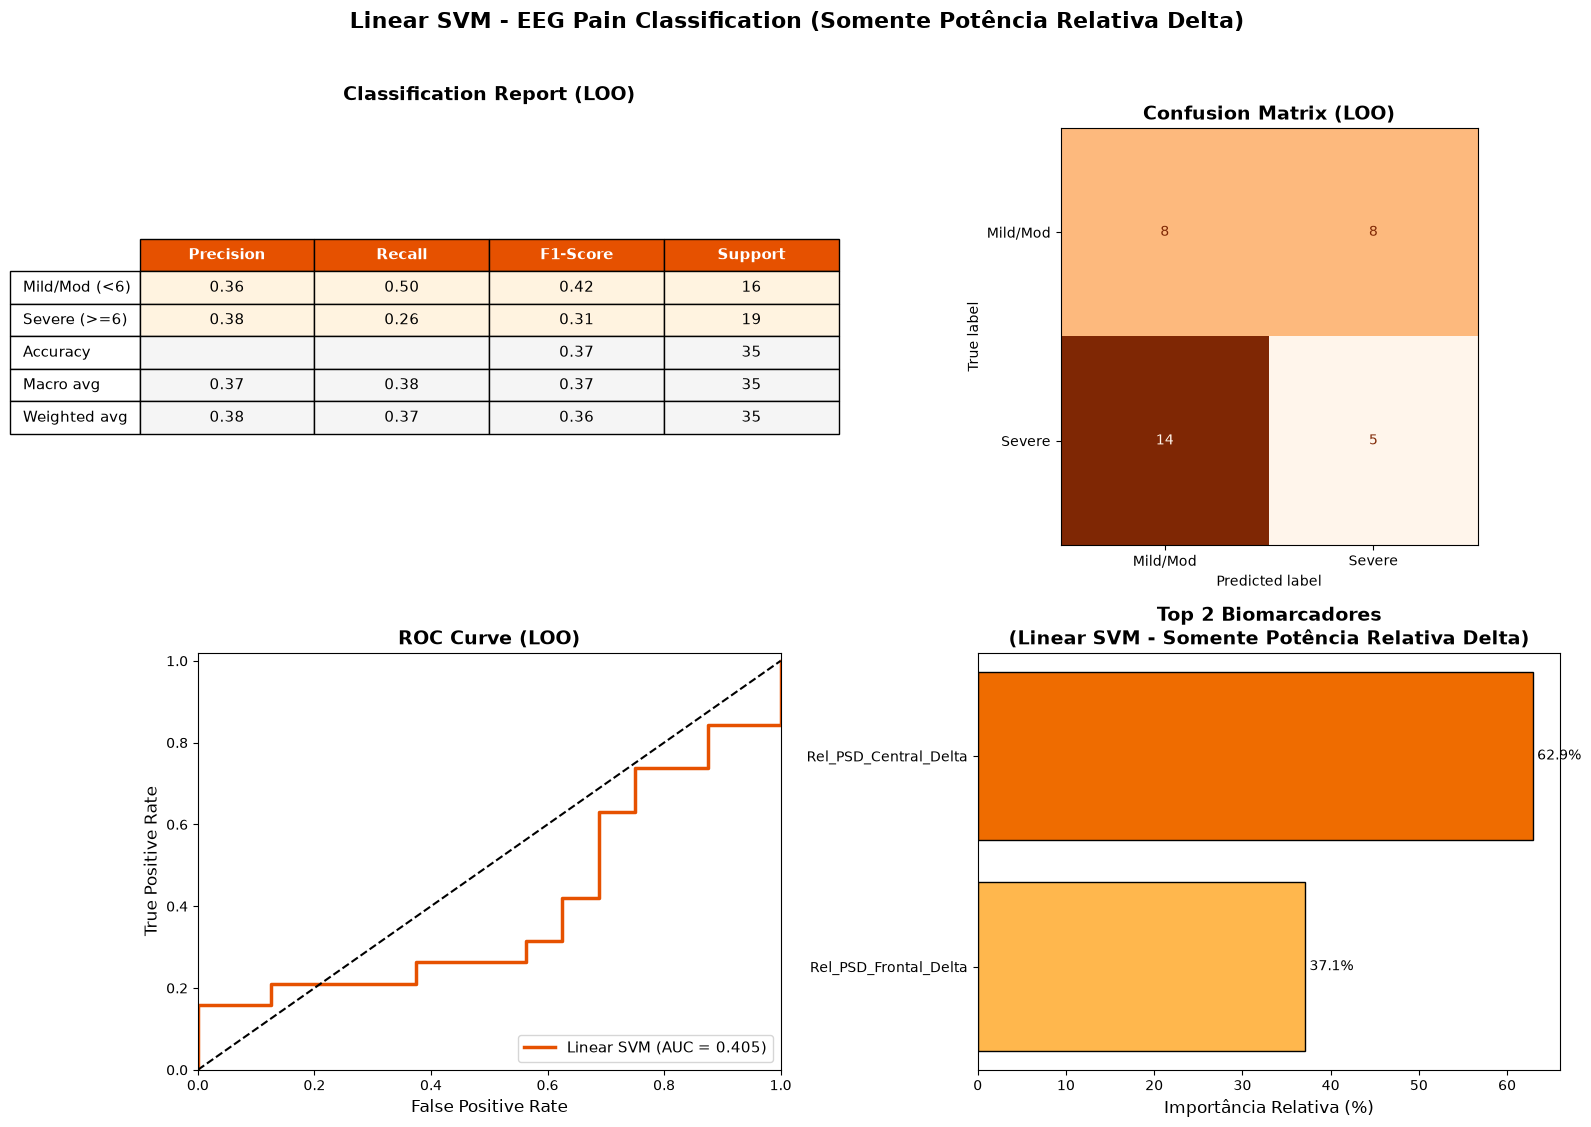


Gráfico salvo como: images\01_rel_psd_delta_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [20]:
# 1. Definir os nomes das features extraindo APENAS as colunas referentes à Potência Relativa de Delta
feature_names = [col for col in df_rel_psd.columns if 'Rel_PSD' in col and 'Delta' in col]

if len(feature_names) == 0:
    feature_names = [col for col in df_rel_psd.columns if 'Delta' in col]

current_category = "Somente Potência Relativa Delta"

# 2. Criar a matriz X (features) e o vetor y (labels) usando o df_rel_psd
X = df_rel_psd[feature_names].values
y = df_rel_psd['pain_score'].values

# O seu código original continua a partir daqui:
if X.shape[0] > 0:
    print('\n' + '=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    # Ajuste dinâmico: evita erro de "index out of bounds" já que temos apenas 2 features (Frontal e Central)
    num_top_features = min(5, len(feature_names_filt)) 

    # Pipeline base com SVM Linear
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para revelar a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")
    
    # Extração de Importância das Features
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_top_features} BIOMARCADORES ({classifier_name}):")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        print(f"  {i}. {feature_names_filt[idx]}: {importances_pct[idx]:.1f}% de importância")

    # --- INÍCIO DO BLOCO DE DIREÇÃO DOS COEFICIENTES ---
    coef_originais = search.best_estimator_.named_steps['svm_final'].coef_[0]
    
    print('-' * 55)
    print(f"\nDIREÇÃO DOS TOP {num_top_features} BIOMARCADORES:")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        valor_coef = coef_originais[idx]
        sinal = "+" if valor_coef > 0 else "-"
        efeito = "AUMENTA" if valor_coef > 0 else "DIMINUI"
        
        print(f"  {i}. {feature_names_filt[idx]}: Coeficiente = {valor_coef:.4f} ({sinal})")
        print(f"     -> Uma potência relativa maior nesta região {efeito} a probabilidade matemática de Dor Severa (Classe 1).")
    # --- FIM DO BLOCO DE DIREÇÃO DOS COEFICIENTES ---

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:num_top_features]
    bios_ordered  = feature_names_filt[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_top_features} Biomarcadores\n({classifier_name} - {current_category})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '01_rel_psd_delta_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1],
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")

### Treinamento SVM (LOO) - Somente Potência espectral relativa de Alfa


Avaliando Linear SVM (Somente Potência Relativa Alfa) - class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 54.3%
LOO AUC-ROC: 0.533

Melhores hiperparâmetros: {'svm_final__C': 10.0}
-------------------------------------------------------

TOP 2 BIOMARCADORES (Linear SVM):
  1. Rel_PSD_Central_Alpha: 55.4% de importância
  2. Rel_PSD_Frontal_Alpha: 44.6% de importância
-------------------------------------------------------

DIREÇÃO DOS TOP 2 BIOMARCADORES:
  1. Rel_PSD_Central_Alpha: Coeficiente = -2.3686 (-)
     -> Uma potência relativa maior nesta região DIMINUI a probabilidade matemática de Dor Severa (Classe 1).
  2. Rel_PSD_Frontal_Alpha: Coeficiente = 1.9032 (+)
     -> Uma potência relativa maior nesta região AUMENTA a probabilidade matemática de Dor Severa (Classe 1).


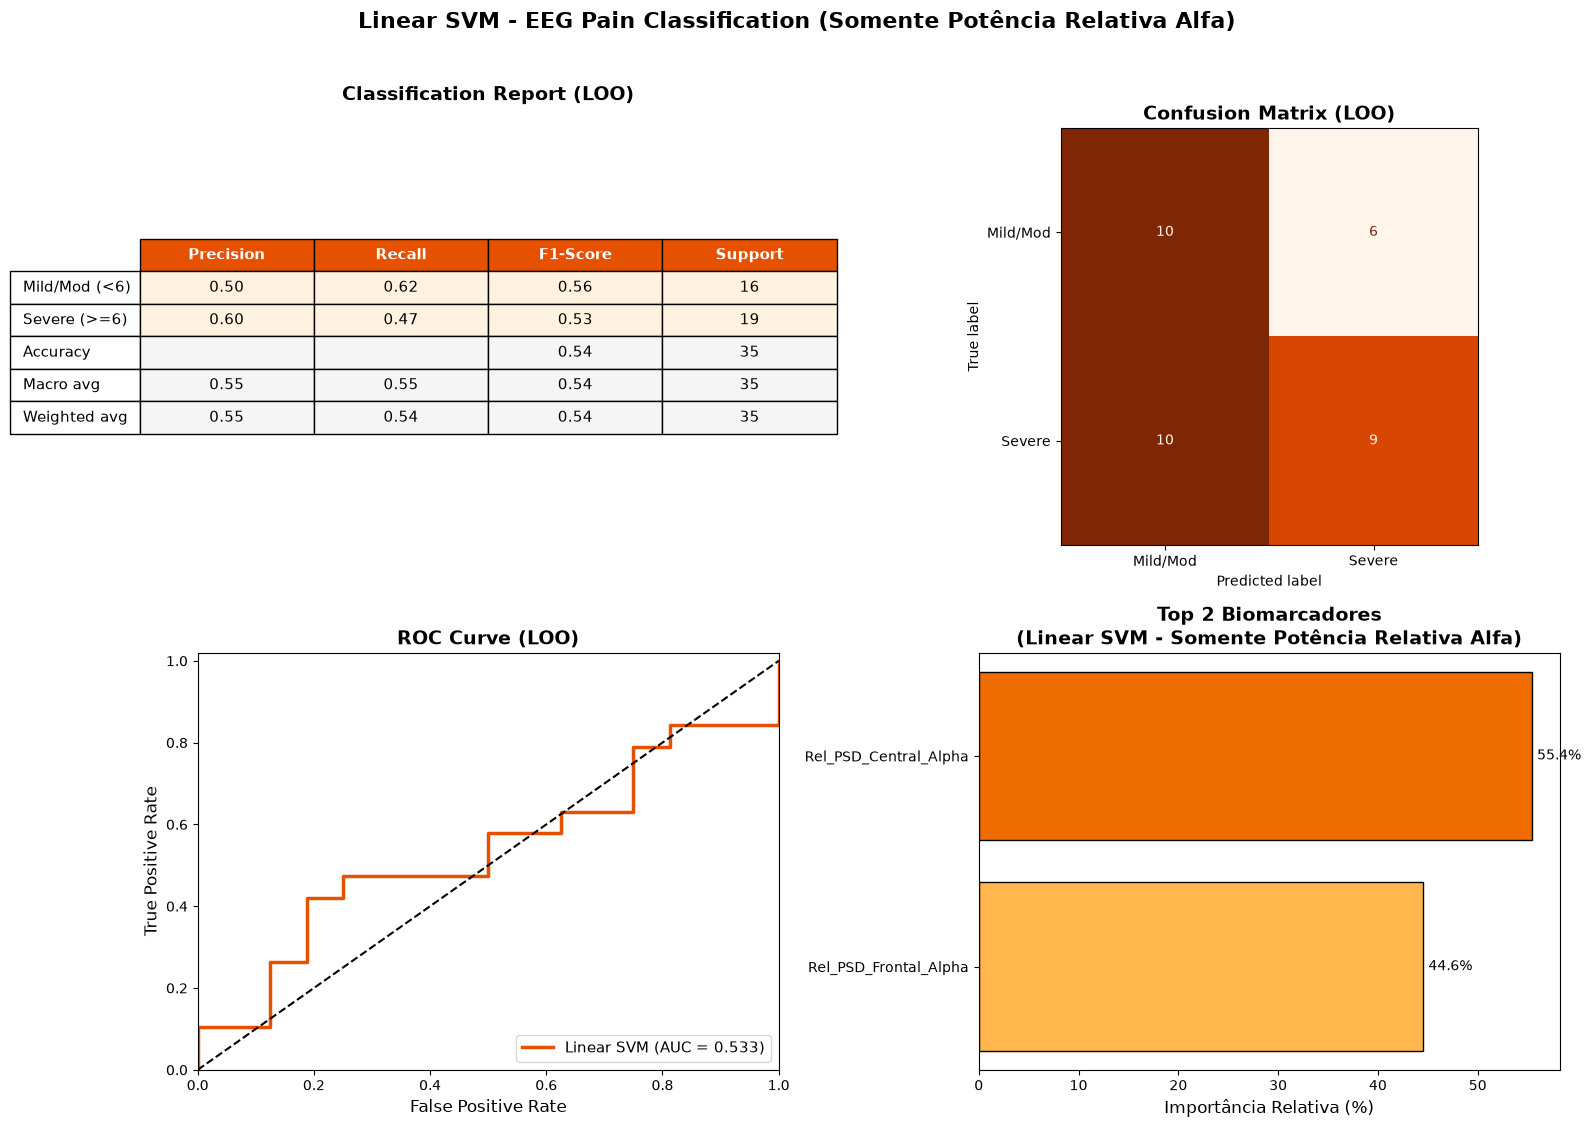


Gráfico salvo como: images\01_rel_psd_alpha_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [21]:
# 1. Definir os nomes das features extraindo APENAS as colunas referentes à Potência Relativa de Alfa
feature_names = [col for col in df_rel_psd.columns if 'Rel_PSD' in col and 'Alpha' in col]

if len(feature_names) == 0:
    feature_names = [col for col in df_rel_psd.columns if 'Alpha' in col]

current_category = "Somente Potência Relativa Alfa"

# 2. Criar a matriz X (features) e o vetor y (labels) usando o df_rel_psd
X = df_rel_psd[feature_names].values
y = df_rel_psd['pain_score'].values

# O seu código original continua a partir daqui:
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando {classifier_name} ({current_category}) - class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    # Ajuste dinâmico: evita erro de "index out of bounds" já que temos poucas features
    num_top_features = min(5, len(feature_names_filt)) 

    # Pipeline base com SVM Linear
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para revelar a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")
    
    # Extração de Importância das Features
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_top_features} BIOMARCADORES ({classifier_name}):")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        print(f"  {i}. {feature_names_filt[idx]}: {importances_pct[idx]:.1f}% de importância")

    # --- INÍCIO DO BLOCO DE DIREÇÃO DOS COEFICIENTES ---
    coef_originais = search.best_estimator_.named_steps['svm_final'].coef_[0]
    
    print('-' * 55)
    print(f"\nDIREÇÃO DOS TOP {num_top_features} BIOMARCADORES:")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        valor_coef = coef_originais[idx]
        sinal = "+" if valor_coef > 0 else "-"
        efeito = "AUMENTA" if valor_coef > 0 else "DIMINUI"
        
        print(f"  {i}. {feature_names_filt[idx]}: Coeficiente = {valor_coef:.4f} ({sinal})")
        print(f"     -> Uma potência relativa maior nesta região {efeito} a probabilidade matemática de Dor Severa (Classe 1).")
    # --- FIM DO BLOCO DE DIREÇÃO DOS COEFICIENTES ---

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:num_top_features]
    bios_ordered  = feature_names_filt[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_top_features} Biomarcadores\n({classifier_name} - {current_category})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '01_rel_psd_alpha_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1],
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")

### Treinamento SVM (LOO) -  Somente Potência espectral relativa de Delta e Alfa


Avaliando Linear SVM (Somente Potência Relativa Delta e Alfa) - class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 45.7%
LOO AUC-ROC: 0.414

Melhores hiperparâmetros: {'svm_final__C': 5.0}
-------------------------------------------------------

TOP 4 BIOMARCADORES (Linear SVM):
  1. Rel_PSD_Frontal_Alpha: 38.0% de importância
  2. Rel_PSD_Central_Alpha: 33.8% de importância
  3. Rel_PSD_Central_Delta: 21.0% de importância
  4. Rel_PSD_Frontal_Delta: 7.3% de importância
-------------------------------------------------------

DIREÇÃO DOS TOP 4 BIOMARCADORES:
  1. Rel_PSD_Frontal_Alpha: Coeficiente = 1.2853 (+)
     -> Uma potência relativa maior nesta região AUMENTA a probabilidade matemática de Dor Severa (Classe 1).
  2. Rel_PSD_Central_Alpha: Coeficiente = -1.1432 (-)
     -> Uma potência relativa maior nesta região DIMINUI a probabilidade matemática d

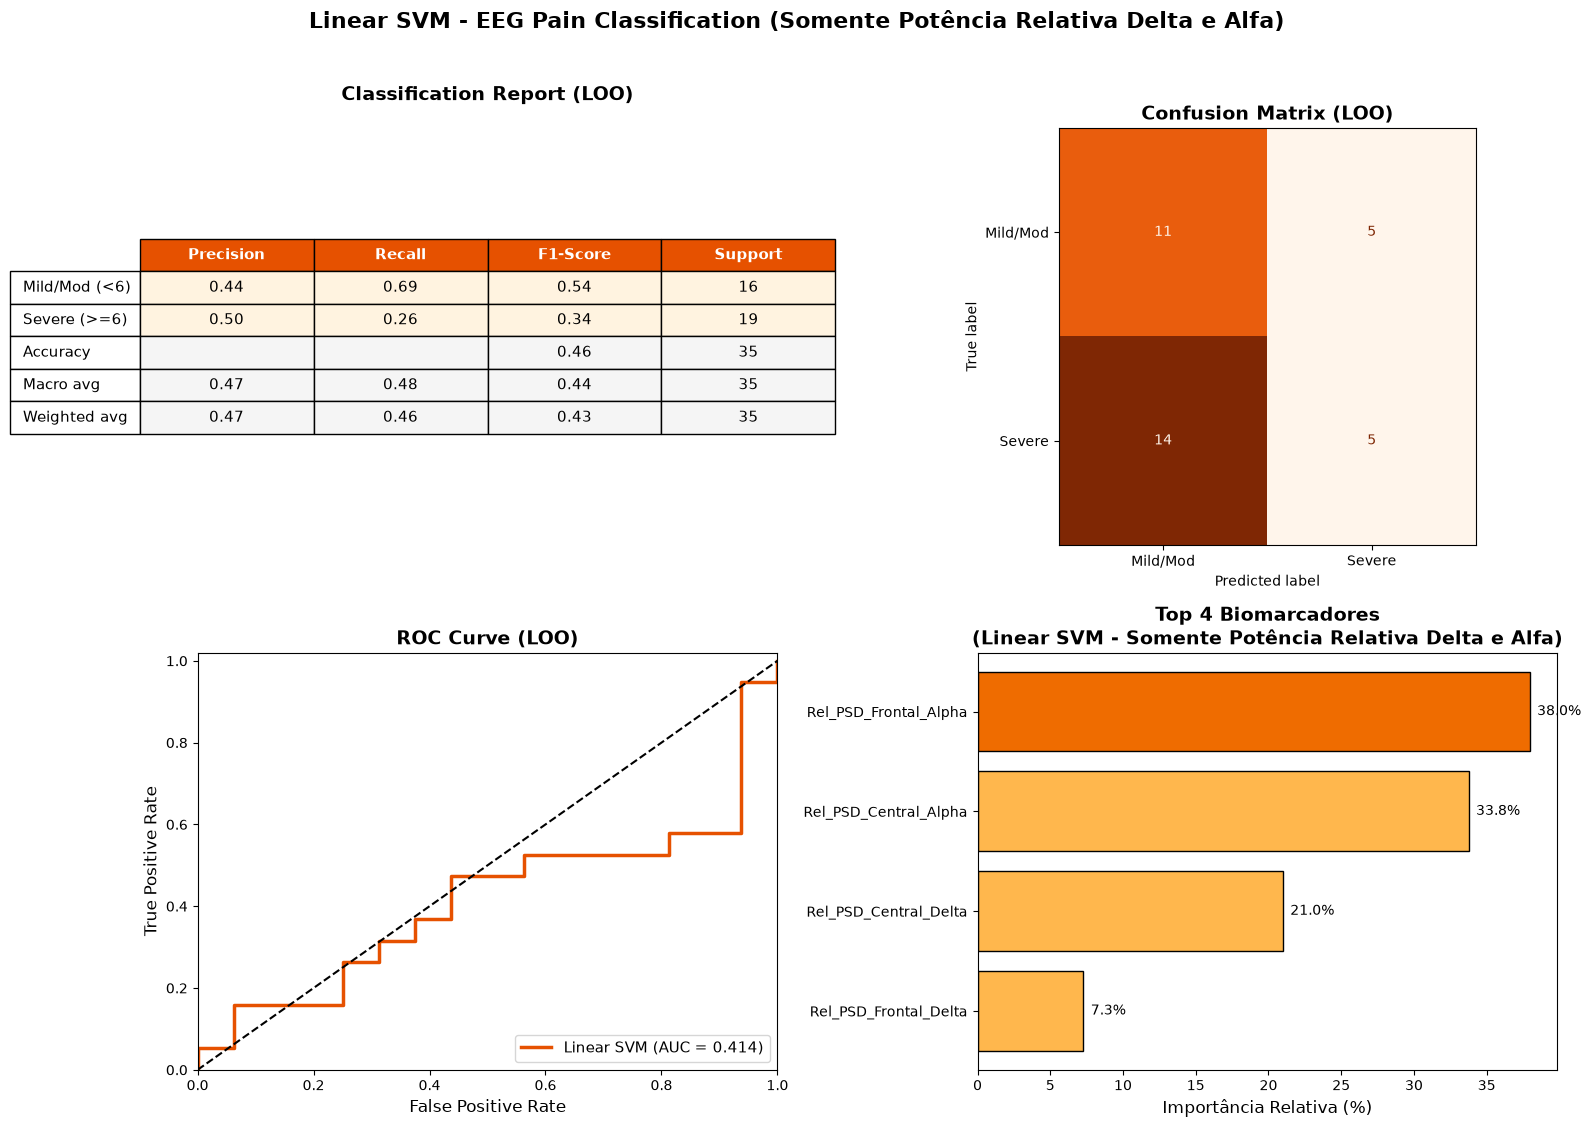


Gráfico salvo como: images\01_rel_psd_delta_alpha_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [22]:
# 1. Definir os nomes das features extraindo APENAS as colunas referentes à Potência Relativa de Delta e Alfa
feature_names = [col for col in df_rel_psd.columns if 'Rel_PSD' in col and ('Delta' in col or 'Alpha' in col)]

if len(feature_names) == 0:
    feature_names = [col for col in df_rel_psd.columns if ('Delta' in col or 'Alpha' in col)]

current_category = "Somente Potência Relativa Delta e Alfa"

# 2. Criar a matriz X (features) e o vetor y (labels) usando o df_rel_psd
X = df_rel_psd[feature_names].values
y = df_rel_psd['pain_score'].values

# O seu código original continua a partir daqui:
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando {classifier_name} ({current_category}) - class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    # Ajuste dinâmico: evita erro de "index out of bounds" já que temos poucas features
    num_top_features = min(5, len(feature_names_filt)) 

    # Pipeline base com SVM Linear
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para revelar a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")
    
    # Extração de Importância das Features
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_top_features} BIOMARCADORES ({classifier_name}):")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        print(f"  {i}. {feature_names_filt[idx]}: {importances_pct[idx]:.1f}% de importância")

    # --- INÍCIO DO BLOCO DE DIREÇÃO DOS COEFICIENTES ---
    coef_originais = search.best_estimator_.named_steps['svm_final'].coef_[0]
    
    print('-' * 55)
    print(f"\nDIREÇÃO DOS TOP {num_top_features} BIOMARCADORES:")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        valor_coef = coef_originais[idx]
        sinal = "+" if valor_coef > 0 else "-"
        efeito = "AUMENTA" if valor_coef > 0 else "DIMINUI"
        
        print(f"  {i}. {feature_names_filt[idx]}: Coeficiente = {valor_coef:.4f} ({sinal})")
        print(f"     -> Uma potência relativa maior nesta região {efeito} a probabilidade matemática de Dor Severa (Classe 1).")
    # --- FIM DO BLOCO DE DIREÇÃO DOS COEFICIENTES ---

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:num_top_features]
    bios_ordered  = feature_names_filt[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_top_features} Biomarcadores\n({classifier_name} - {current_category})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '01_rel_psd_delta_alpha_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1],
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")